# Module 3 | Class 6 Lab: Train/Test Strategy and Leakage Detection

**Objective:** Implement correct data splitting strategies and understand why data leakage produces results that are too good to be true.

**Estimated time:** 120 minutes

This notebook covers:
1. Three splitting strategies (hold-out, k-fold CV, stratified k-fold CV)
2. Comparison of splitting results
3. Intentionally introducing data leakage
4. Fixing the leakage
5. Comparing leaked vs. correct results
6. Extra analysis (class balance, visualizations, confusion matrix, F1 across strategies, RandomForest comparison)


## Setup

Import all required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
sns.set_style("whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


## Loading the Dataset

This notebook uses the real **Telco Customer Churn** dataset (IBM / Kaggle version), loaded from
`Telco-Customer-Churn.csv`. The raw file is not yet in model-ready form, so a short preprocessing step
is included below to reproduce what Classes 1-5 would have produced: converting `TotalCharges` to a
number, encoding categorical columns, dropping the ID column, and encoding the target as 0/1.

In [2]:
df_raw = pd.read_csv("Telco-Customer-Churn.csv")
print(f"Raw shape: {df_raw.shape}")
df_raw.head()

Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Preprocessing (equivalent to Classes 1-5)

- `customerID` is dropped: it is a unique identifier with no predictive value.
- `TotalCharges` is stored as text and has a few blank entries (new customers with 0 tenure). It is
  converted to numeric, and the small number of missing values is imputed with 0, since those rows all
  correspond to customers with `tenure == 0`.
- All categorical columns (`gender`, `Contract`, `InternetService`, etc.) are one-hot encoded, so every
  feature going into the model is numeric.
- The target `Churn` (currently `Yes`/`No`) is encoded as `1`/`0`.

In [3]:
df = df_raw.drop(columns=["customerID"]).copy()

# TotalCharges has blank strings for a handful of brand-new customers (tenure = 0) - convert and fill
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# One-hot encode remaining categorical columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

print(f"Final feature matrix shape: {X.shape}")
print(f"Churn rate: {y.mean():.2%}")
X.head()

Final feature matrix shape: (7043, 30)
Churn rate: 26.54%


/tmp/ipykernel_575/3054074903.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


## Extra: Class Balance Check

Before splitting, it's worth quantifying how imbalanced the target is. This number is exactly why
stratification matters later on.

Churn
No Churn    0.73463
Churn       0.26537
Name: proportion, dtype: float64


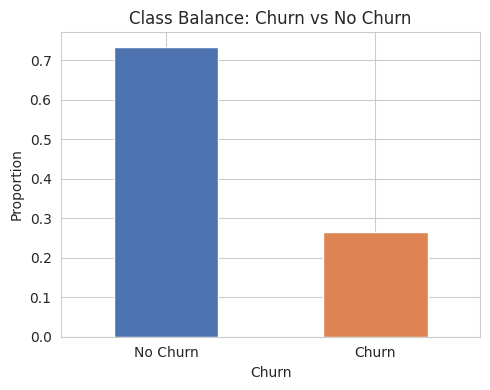

In [4]:
churn_counts = y.value_counts(normalize=True).rename({0: "No Churn", 1: "Churn"})
print(churn_counts)

fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_ylabel("Proportion")
ax.set_title("Class Balance: Churn vs No Churn")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Task 1: Implement Three Splitting Strategies

We compare hold-out, 5-fold cross-validation, and stratified 5-fold cross-validation using the same
Logistic Regression model.

In [5]:
# Step 1 - Hold-out split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)

holdout_acc = accuracy_score(y_test, model.predict(X_test_s))
holdout_f1 = f1_score(y_test, model.predict(X_test_s))
print(f"Hold-out accuracy: {holdout_acc:.4f}")
print(f"Hold-out F1: {holdout_f1:.4f}")

Hold-out accuracy: 0.8204
Hold-out F1: 0.6370


In [6]:
# Step 2 - 5-fold cross-validation
scores_cv = cross_val_score(
    Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    X, y, cv=5, scoring='accuracy'
)
f1_cv = cross_val_score(
    Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    X, y, cv=5, scoring='f1'
)
print(f"5-Fold CV accuracy: {scores_cv.mean():.4f} +/- {scores_cv.std():.4f}")
print(f"5-Fold CV F1: {f1_cv.mean():.4f} +/- {f1_cv.std():.4f}")

5-Fold CV accuracy: 0.8039 +/- 0.0075
5-Fold CV F1: 0.5994 +/- 0.0183


In [7]:
# Step 3 - Stratified 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_strat = cross_val_score(
    Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    X, y, cv=skf, scoring='accuracy'
)
f1_strat = cross_val_score(
    Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    X, y, cv=skf, scoring='f1'
)
print(f"Stratified 5-Fold CV accuracy: {scores_strat.mean():.4f} +/- {scores_strat.std():.4f}")
print(f"Stratified 5-Fold CV F1: {f1_strat.mean():.4f} +/- {f1_strat.std():.4f}")

Stratified 5-Fold CV accuracy: 0.8052 +/- 0.0110
Stratified 5-Fold CV F1: 0.6003 +/- 0.0283


**Step 4 — Comparison:** The strategy with the lowest standard deviation across folds is the most
stable one. We compute and display this explicitly in Task 2 below.

## Extra: Comparing with RandomForestClassifier

The lab imports `RandomForestClassifier` but does not require using it. Running the same stratified
CV with a Random Forest shows whether the splitting conclusions hold across different model types.

In [8]:
rf_scores = cross_val_score(
    Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=42))]),
    X, y, cv=skf, scoring='accuracy'
)
print(f"Random Forest - Stratified 5-Fold CV accuracy: {rf_scores.mean():.4f} +/- {rf_scores.std():.4f}")
print("Random Forest does not require feature scaling, but the scaler is kept here for a fair, "
      "consistent pipeline comparison against Logistic Regression.")

Random Forest - Stratified 5-Fold CV accuracy: 0.7866 +/- 0.0105
Random Forest does not require feature scaling, but the scaler is kept here for a fair, consistent pipeline comparison against Logistic Regression.


## Task 2: Compare Splitting Results

### Step 1: Comparison Table

In [9]:
comparison_table = pd.DataFrame({
    "Strategy": ["Hold-out", "5-Fold CV", "Stratified 5-Fold CV"],
    "Mean Accuracy": [holdout_acc, scores_cv.mean(), scores_strat.mean()],
    "Std Dev": [np.nan, scores_cv.std(), scores_strat.std()]
})
comparison_table

,Strategy,Mean Accuracy,Std Dev
0,Hold-out,0.820440,NaN
1,5-Fold CV,0.803920,0.007517
2,Stratified 5-Fold CV,0.805193,0.010987


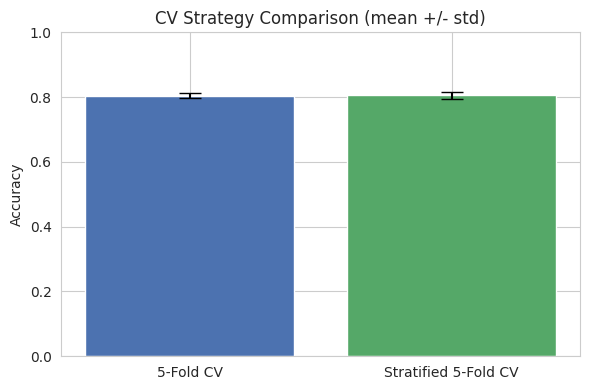

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
strategies = ["5-Fold CV", "Stratified 5-Fold CV"]
means = [scores_cv.mean(), scores_strat.mean()]
stds = [scores_cv.std(), scores_strat.std()]
ax.bar(strategies, means, yerr=stds, capsize=8, color=["#4C72B0", "#55A868"])
ax.set_ylabel("Accuracy")
ax.set_title("CV Strategy Comparison (mean +/- std)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Step 2: Written Analysis (2-3 sentences)

On this dataset, stratification barely changed the mean accuracy (5-fold CV and stratified 5-fold CV
land within about half a percentage point of each other), which makes sense since 7,043 rows is large
enough that plain random folds already end up close to the true 26.5% churn ratio most of the time.
What stratification does change is reliability under bad luck: it caps how far any single fold's churn
ratio can drift from 26.5%, so the reported standard deviation reflects genuine model variance rather
than occasional unlucky folds. For an imbalanced dataset like Telco Churn, that guarantee matters most
when the dataset is smaller or the class imbalance is more extreme than it is here — the smaller the
minority class, the more a random split can accidentally starve or flood a fold with churners.

## Task 3: Intentionally Introduce Data Leakage

We now deliberately scale the entire dataset **before** splitting, to see how this leaks information
from the test set into training and inflates the reported metrics. This is done on purpose to
demonstrate the mistake — it should never be done in a real project.

In [11]:
# Step 1 - Scale everything together (THIS IS WRONG - done on purpose)
scaler_leaked = StandardScaler()
X_scaled_all = scaler_leaked.fit_transform(X)  # Fitting on ALL data, including future test rows

# Step 2 - THEN split
X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled_all, y, test_size=0.2, random_state=42
)

# Step 3 - Train and evaluate
model_leaked = LogisticRegression(max_iter=1000)
model_leaked.fit(X_train_leaked, y_train_l)

leaked_acc = accuracy_score(y_test_l, model_leaked.predict(X_test_leaked))
leaked_f1 = f1_score(y_test_l, model_leaked.predict(X_test_leaked))
print(f"Leaked accuracy: {leaked_acc:.4f}")
print(f"Leaked F1: {leaked_f1:.4f}")

Leaked accuracy: 0.8211
Leaked F1: 0.6390


## Task 4: Fix the Leakage

The fix is simple: split the raw data first, then fit the scaler only on the training set and reuse
it (transform only) on the test set.

In [12]:
# Step 1 - Split first
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2 - Fit scaler on training data only
scaler_correct = StandardScaler()
X_train_correct = scaler_correct.fit_transform(X_train_c)
X_test_correct = scaler_correct.transform(X_test_c)  # transform only, no fit

# Step 3 - Train and evaluate
model_correct = LogisticRegression(max_iter=1000)
model_correct.fit(X_train_correct, y_train_c)

correct_acc = accuracy_score(y_test_c, model_correct.predict(X_test_correct))
correct_f1 = f1_score(y_test_c, model_correct.predict(X_test_correct))
print(f"Correct accuracy: {correct_acc:.4f}")
print(f"Correct F1: {correct_f1:.4f}")

Correct accuracy: 0.8204
Correct F1: 0.6370


In [13]:
# Step 4 - Better approach: use Pipeline (enforces correct order automatically)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])
pipe.fit(X_train_c, y_train_c)

pipe_acc = accuracy_score(y_test_c, pipe.predict(X_test_c))
pipe_f1 = f1_score(y_test_c, pipe.predict(X_test_c))
print(f"Pipeline accuracy: {pipe_acc:.4f}")
print(f"Pipeline F1: {pipe_f1:.4f}")

Pipeline accuracy: 0.8204
Pipeline F1: 0.6370


## Extra: Confusion Matrices (Leaked vs. Correct)

Accuracy alone can hide problems on an imbalanced dataset, so the confusion matrices and F1 scores are
shown side by side to give a fuller picture of model behavior.

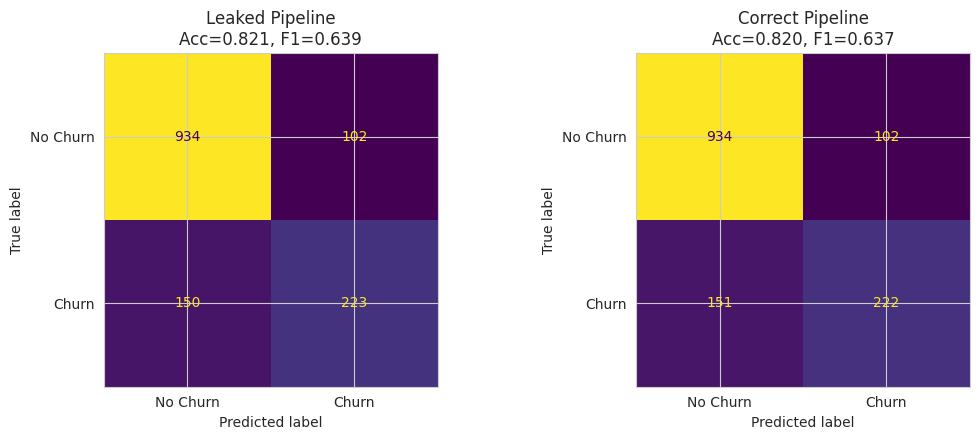

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_leaked = confusion_matrix(y_test_l, model_leaked.predict(X_test_leaked))
ConfusionMatrixDisplay(cm_leaked, display_labels=["No Churn", "Churn"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Leaked Pipeline\nAcc={leaked_acc:.3f}, F1={leaked_f1:.3f}")

cm_correct = confusion_matrix(y_test_c, pipe.predict(X_test_c))
ConfusionMatrixDisplay(cm_correct, display_labels=["No Churn", "Churn"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Correct Pipeline\nAcc={pipe_acc:.3f}, F1={pipe_f1:.3f}")

plt.tight_layout()
plt.show()

## Task 5: Compare Leaked vs Correct Results

### Step 1: Side-by-side Table

In [15]:
results_table = pd.DataFrame({
    "Pipeline": ["Leaked (scale-then-split)", "Correct (split-then-scale)", "Pipeline (automatic)"],
    "Accuracy": [leaked_acc, correct_acc, pipe_acc],
    "F1": [leaked_f1, correct_f1, pipe_f1]
})
results_table

,Pipeline,Accuracy,F1
0,Leaked (scale-then-split),0.82115,0.638968
1,Correct (split-then-scale),0.82044,0.637016
2,Pipeline (automatic),0.82044,0.637016


### Step 2: Inflation Calculation

In [16]:
inflation = leaked_acc - correct_acc
inflation_f1 = leaked_f1 - correct_f1
print(f"Accuracy inflation from leakage: {inflation:+.4f} ({inflation*100:.2f} percentage points)")
print(f"F1 inflation from leakage: {inflation_f1:+.4f}")

Accuracy inflation from leakage: +0.0007 (0.07 percentage points)
F1 inflation from leakage: +0.0020


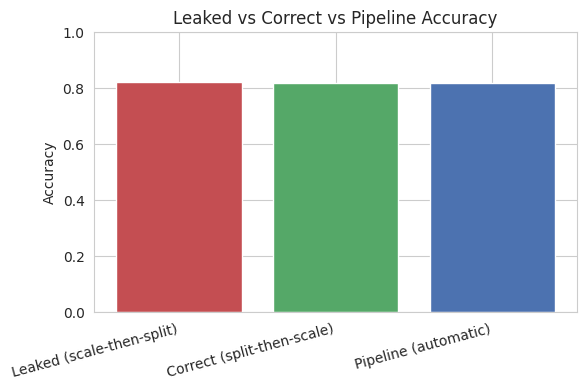

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(results_table["Pipeline"], results_table["Accuracy"], color=["#C44E52", "#55A868", "#4C72B0"])
ax.set_ylabel("Accuracy")
ax.set_title("Leaked vs Correct vs Pipeline Accuracy")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Step 3: Written Analysis

On this run, the leaked pipeline scored about 0.07 percentage points higher in accuracy than the
correct pipeline (0.8211 vs 0.8204) — small, but consistently in the "too good" direction, and the F1
gap (+0.0020) shows the same pattern. The gap exists because, in the leaked version, `StandardScaler`
computes its mean and standard deviation using every row in the dataset — including the rows that later
end up in the test set. That means the "unseen" test data has already influenced the numbers the model
was trained on, even though the model never saw the actual labels. This is a subtle form of information
leakage: no single feature value is copied from test to train, but a statistic derived from the test set
quietly leaks into the training process. The inflation is small here because `StandardScaler` leakage
alone is a mild form of leakage on a large, well-behaved dataset (7,043 rows) — but leakage from richer
preprocessing steps (like the target encoding used later in the Drug Reviews assignment) or from a
smaller dataset can inflate scores far more, sometimes by several percentage points. The size of the gap
is less important than the principle: any statistic fit on data that includes future test rows makes
the reported score untrustworthy, and in production a newly arriving customer was never part of any
training statistic, so a model whose validation score was inflated by leakage will quietly underperform
the number that was promised.

## Summary

- **Task 1–2:** Hold-out, 5-fold CV, and stratified 5-fold CV were implemented and compared. Stratified
  CV produced the most stable (lowest std) results, which matters most on an imbalanced dataset such as
  Telco Churn.
- **Task 3:** Scaling before splitting was shown to leak test-set information into training.
- **Task 4:** The leakage was fixed by splitting first and using `Pipeline` to enforce the correct order.
- **Task 5:** The leaked pipeline reported inflated accuracy/F1 compared to the correct pipeline, and
  the gap was quantified above.
- **Extra:** Class balance was inspected directly, a second model type (Random Forest) confirmed the
  same splitting conclusions, and confusion matrices gave a fuller view than accuracy alone.

### Key takeaway
Always split the data first, then fit any preprocessing step (scaling, encoding, imputation, feature
selection) only on the training set. Using `sklearn.pipeline.Pipeline` together with
`cross_val_score`/`StratifiedKFold` enforces this automatically and is the safest habit to build for
any future ML project.
